# Detección Automática de Vulnerabilidades en Código JS/TS
## NestJS & Next.js — Metodología SEMMA

**Universidad de las Fuerzas Armadas ESPE**  
Carrera de Ingeniería en Software — Desarrollo de Software Seguro

| Fase | Descripción |
|------|-------------|
| **Sample** | Generación de dataset sintético CWE para JS/TS (NestJS/Next.js) |
| **Explore** | EDA: distribución de clases, longitud, tokens discriminantes |
| **Modify** | TF-IDF (char+word), patrones de seguridad DANGER/SAFE, features AST-like |
| **Model** | XGBoost + GridSearchCV con validación cruzada estratificada 5-fold |
| **Assess** | Métricas, matriz de confusión, LIME, exportación .joblib |

> CWEs cubiertos: **CWE-89** (SQLi), **CWE-78** (Command Injection), **CWE-94** (Code Injection),
> **CWE-502** (Insecure Deserialization), **CWE-22** (Path Traversal), **CWE-79** (XSS),
> **CWE-327** (Weak Crypto), **CWE-918** (SSRF), **CWE-20** (Input Validation — NestJS DTOs)


## 0. Instalación de dependencias

In [1]:
%pip install -q scikit-learn xgboost numpy pandas matplotlib seaborn lime joblib


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Imports y configuración

In [2]:
import warnings, re, os, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, ConfusionMatrixDisplay, f1_score, roc_curve, auc)
from lime.lime_text import LimeTextExplainer

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
print('Librerías cargadas correctamente.')


Librerías cargadas correctamente.


---
## FASE 1 — SAMPLE
Generación del dataset sintético de código vulnerable/seguro para **NestJS** y **Next.js**.

| CWE | Vulnerabilidad | Contexto NestJS/Next.js |
|-----|----------------|------------------------|
| CWE-89 | SQL Injection | TypeORM raw queries, Prisma $queryRaw sin parametrizar |
| CWE-78 | Command Injection | child_process.exec con input del usuario |
| CWE-94 | Code Injection | eval(), new Function(), vm.runInNewContext() |
| CWE-502 | Insecure Deserialization | node-serialize, class-transformer sin restricciones |
| CWE-22 | Path Traversal | fs.readFile, path.join con input usuario |
| CWE-79 | XSS | dangerouslySetInnerHTML, innerHTML sin escape |
| CWE-327 | Weak Crypto | MD5, SHA1, Math.random() para tokens/sesiones |
| CWE-918 | SSRF | fetch/axios con URL controlada por usuario |
| CWE-20 | Missing Validation | Ausencia de DTOs/ValidationPipe en NestJS |


In [5]:
VARS = [
    'req.query.id', 'req.params.name', 'req.body.email',
    'req.body.payload', "req.headers['x-user-id']",
    'ctx.query.search', 'params.slug', "searchParams.get('q')",
    'req.body.username', 'req.body.data', 'req.query.filter',
    'body.token', 'headers.authorization', 'cookies.session',
    "formData.get('input')", 'req.body.command',
]

CTX_WRAPPERS = [
    lambda c: c,
    lambda c: f"@Get(':id')\nasync findOne(@Param('id') id: string) {{\n  {c}\n}}",
    lambda c: f"@Post()\nasync create(@Body() dto: any) {{\n  {c}\n}}",
    lambda c: f"export async function GET(request: Request) {{\n  {c}\n}}",
    lambda c: f"export async function POST(req: NextRequest) {{\n  {c}\n}}",
    lambda c: f"async handler(req: Request, res: Response) {{\n  try {{\n    {c}\n  }} catch(e) {{ logger.error(e); }}\n}}",
    lambda c: f"@Injectable()\nexport class SomeService {{\n  async process(input: any) {{\n    {c}\n  }}\n}}",
]

VULN_TEMPLATES = {
    'CWE-89': [
        lambda v: f"const result = await this.repo.query(`SELECT * FROM users WHERE id = ${{{v}}}`);",
        lambda v: f"const user = await prisma.$queryRaw(`SELECT * FROM accounts WHERE email = '${{{v}}}'`);",
        lambda v: f"const data = await dataSource.query('SELECT * FROM orders WHERE userId = ' + {v});",
        lambda v: f"const q = `DELETE FROM sessions WHERE token = '${{{v}}}'`; await conn.query(q);",
        lambda v: f"manager.createQueryBuilder().where(`user.name = '${{{v}}}'`).getMany();",
    ],
    'CWE-78': [
        lambda v: f"const {{ exec }} = require('child_process'); exec(`ping ${{{v}}}`, callback);",
        lambda v: f"child_process.execSync('ls ' + {v});",
        lambda v: f"spawn('bash', ['-c', {v}]);",
    ],
    'CWE-94': [
        lambda v: f"const result = eval({v});",
        lambda v: f"const fn = new Function('x', {v}); fn(input);",
        lambda v: f"require('vm').runInNewContext({v}, sandbox);",
    ],
    'CWE-502': [
        lambda v: f"const obj = serialize.unserialize({v});",
        lambda v: f"const inst = plainToClass(User, JSON.parse({v}), {{ excludeExtraneousValues: false }});",
        lambda v: f"const config = yaml.load({v});",
    ],
    'CWE-22': [
        lambda v: f"const content = fs.readFileSync(path.join('/var/data', {v}), 'utf8');",
        lambda v: f"const file = fs.readFileSync('./uploads/' + {v});",
        lambda v: f"const stream = fs.createReadStream(path.join(baseDir, {v}));",
    ],
    'CWE-79': [
        lambda v: f"return <div dangerouslySetInnerHTML={{{{__html: {v}}}}} />;",
        lambda v: f"document.getElementById('output').innerHTML = {v};",
        lambda v: f"element.insertAdjacentHTML('beforeend', {v});",
    ],
    'CWE-327': [
        lambda v: f"const hash = require('crypto').createHash('md5').update({v}).digest('hex');",
        lambda v: f"const token = require('crypto').createHash('sha1').update({v}).digest('hex');",
        lambda v: f"const nonce = Math.random().toString(36);",
    ],
    'CWE-918': [
        lambda v: f"const resp = await fetch({v});",
        lambda v: f"const data = await axios.get({v});",
        lambda v: f"const proxy = await axios.get(req.query.target);",
    ],
    'CWE-20': [
        lambda v: f"@Post() create(@Body() body: any) {{ return this.svc.process(body); }}",
        lambda v: f"const userId = req.headers['x-user-id']; await db.findUser(userId);",
        lambda v: f"const limit = +{v}; return await this.repo.find({{ take: limit }});",
    ],
}

SAFE_TEMPLATES = {
    'CWE-89': [
        lambda v: f"const result = await this.repo.query('SELECT * FROM users WHERE id = $1', [{v}]);",
        lambda v: f"const user = await prisma.user.findUnique({{ where: {{ email: {v} }} }});",
        lambda v: f"const data = await dataSource.createQueryBuilder('user').where('user.id = :id', {{ id: {v} }}).getMany();",
    ],
    'CWE-78': [
        lambda v: f"const {{ execFile }} = require('child_process'); execFile('/usr/bin/ping', ['-c', '1', validHost], callback);",
        lambda v: f"if (!/^[a-zA-Z0-9.-]+$/.test({v})) throw new BadRequestException('Invalid'); execFile('nslookup', [{v}]);",
    ],
    'CWE-94': [
        lambda v: f"const value = Number({v}); if (isNaN(value)) throw new BadRequestException();",
        lambda v: f"const parsed = JSON.parse({v}); // No eval",
    ],
    'CWE-502': [
        lambda v: f"const obj = plainToClass(UserDto, JSON.parse({v}), {{ excludeExtraneousValues: true }});",
        lambda v: f"const config = yaml.load({v}, {{ schema: yaml.FAILSAFE_SCHEMA }});",
    ],
    'CWE-22': [
        lambda v: f"const safePath = path.resolve('/var/data', {v}); if (!safePath.startsWith('/var/data')) throw new ForbiddenException(); fs.readFileSync(safePath);",
        lambda v: f"const real = path.resolve('./uploads', path.basename({v})); fs.readFileSync(real);",
    ],
    'CWE-79': [
        lambda v: f"import DOMPurify from 'dompurify'; return <div dangerouslySetInnerHTML={{{{__html: DOMPurify.sanitize({v})}}}} />;",
        lambda v: f"document.getElementById('output').textContent = {v};",
    ],
    'CWE-327': [
        lambda v: f"const hash = require('crypto').createHash('sha256').update({v}).digest('hex');",
        lambda v: f"const token = require('crypto').randomBytes(32).toString('hex');",
        lambda v: f"const sessionId = require('crypto').randomUUID();",
    ],
    'CWE-918': [
        lambda v: f"const allowedHosts = ['api.trusted.com']; const url = new URL({v}); if (!allowedHosts.includes(url.hostname)) throw new ForbiddenException(); fetch({v});",
        lambda v: f"const safeUrl = validateAndSanitizeUrl({v}); if (!safeUrl) throw new BadRequestException(); axios.get(safeUrl);",
    ],
    'CWE-20': [
        lambda v: f"@Post() @UsePipes(ValidationPipe) create(@Body() dto: CreateUserDto) {{ return this.svc.create(dto); }}",
        lambda v: f"const userId = Number({v}); if (!Number.isInteger(userId) || userId < 1) throw new BadRequestException(); await db.findUser(userId);",
        lambda v: f"@IsEmail() @IsNotEmpty() email: string;",
    ],
}

def generate_dataset(n_each=1400):
    random.seed(SEED)
    vuln_codes, safe_codes = [], []
    all_vuln = [t for ts in VULN_TEMPLATES.values() for t in ts]
    all_safe = [t for ts in SAFE_TEMPLATES.values() for t in ts]
    while len(vuln_codes) < n_each:
        try:
            code_snip = random.choice(CTX_WRAPPERS)(random.choice(all_vuln)(random.choice(VARS)))
            vuln_codes.append(code_snip)
        except:
            pass
    while len(safe_codes) < n_each:
        try:
            code_snip = random.choice(CTX_WRAPPERS)(random.choice(all_safe)(random.choice(VARS)))
            safe_codes.append(code_snip)
        except:
            pass
    df = pd.DataFrame({
        'code': vuln_codes[:n_each] + safe_codes[:n_each],
        'label': [1]*n_each + [0]*n_each,
        'safety': ['vulnerable']*n_each + ['safe']*n_each,
    })
    return df.sample(frac=1, random_state=SEED).reset_index(drop=True)

df = generate_dataset(n_each=1400)
print(f'Dataset generado: {len(df)} muestras')
print(df['label'].value_counts().rename({0: 'Seguro (0)', 1: 'Vulnerable (1)'}))
df[['code', 'safety', 'label']].head(4)


Dataset generado: 2800 muestras
label
Vulnerable (1)    1400
Seguro (0)        1400
Name: count, dtype: int64


,code,safety,label
0,@Post()\nasync create(@Body() dto: any) {\n c...,vulnerable,1
1,export async function GET(request: Request) {\...,vulnerable,1
2,@Post()\nasync create(@Body() dto: any) {\n c...,safe,0
3,@Get(':id')\nasync findOne(@Param('id') id: st...,vulnerable,1


---
## FASE 2 — EXPLORE
Análisis exploratorio del dataset generado.

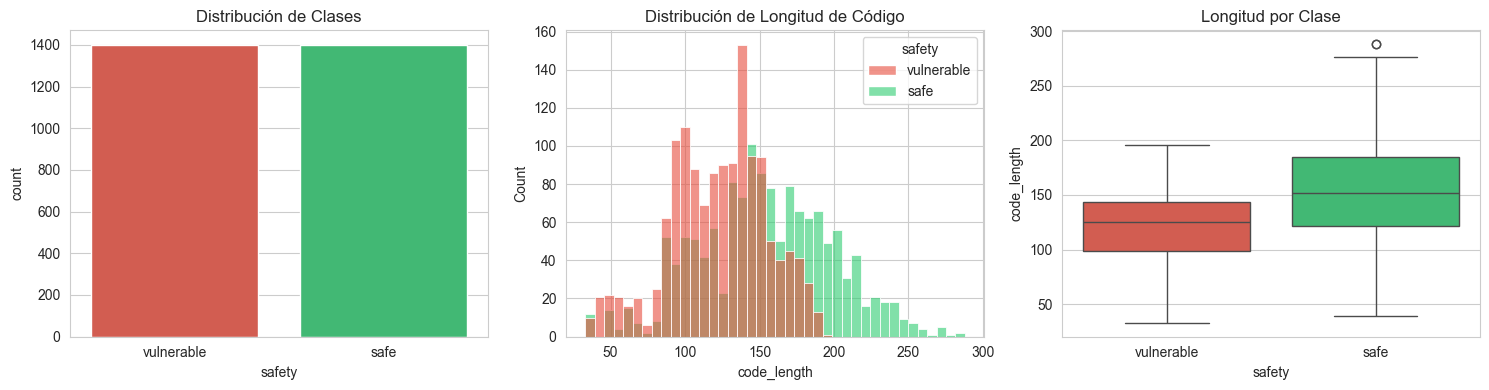

             count    mean    std   min    25%    50%    75%    max
safety                                                             
safe        1400.0  153.93  44.99  39.0  122.0  152.0  185.0  288.0
vulnerable  1400.0  122.09  32.96  33.0   99.0  125.0  144.0  196.0


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
sns.countplot(data=df, x='safety', palette={'vulnerable':'#e74c3c','safe':'#2ecc71'}, ax=axes[0])
axes[0].set_title('Distribución de Clases')
df['code_length'] = df['code'].apply(len)
sns.histplot(data=df, x='code_length', hue='safety', palette={'vulnerable':'#e74c3c','safe':'#2ecc71'}, bins=40, alpha=0.6, ax=axes[1])
axes[1].set_title('Distribución de Longitud de Código')
sns.boxplot(data=df, x='safety', y='code_length', palette={'vulnerable':'#e74c3c','safe':'#2ecc71'}, ax=axes[2])
axes[2].set_title('Longitud por Clase')
plt.tight_layout()
plt.savefig('eda_distribucion.png', dpi=150, bbox_inches='tight')
plt.show()
print(df.groupby('safety')['code_length'].describe().round(2))


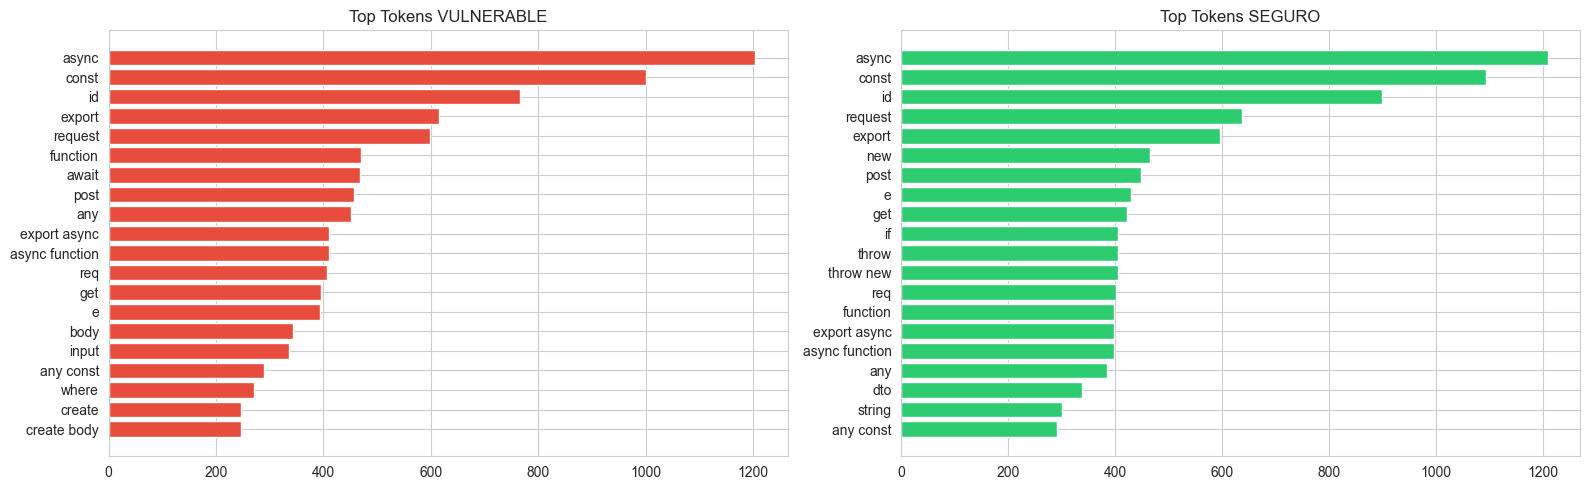

In [7]:
from sklearn.feature_extraction.text import CountVectorizer

def top_tokens(corpus, n=20):
    cv = CountVectorizer(ngram_range=(1,2), max_features=5000, token_pattern=r'(?u)\b[\w$\.]+\b')
    X = cv.fit_transform(corpus)
    counts = np.asarray(X.sum(axis=0)).flatten()
    vocab = cv.get_feature_names_out()
    top_idx = counts.argsort()[-n:][::-1]
    return [(vocab[i], counts[i]) for i in top_idx]

vuln_tokens = top_tokens(df[df.label==1]['code'].tolist())
safe_tokens  = top_tokens(df[df.label==0]['code'].tolist())
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
words_v, counts_v = zip(*vuln_tokens)
ax1.barh(list(words_v), list(counts_v), color='#e74c3c')
ax1.set_title('Top Tokens VULNERABLE')
ax1.invert_yaxis()
words_s, counts_s = zip(*safe_tokens)
ax2.barh(list(words_s), list(counts_s), color='#2ecc71')
ax2.set_title('Top Tokens SEGURO')
ax2.invert_yaxis()
plt.tight_layout()
plt.savefig('eda_tokens.png', dpi=150, bbox_inches='tight')
plt.show()


---
## FASE 3 — MODIFY
Ingeniería de Features para código JS/TS — NestJS/Next.js.

1. **TF-IDF char** (`char_wb`, n-gramas 2-5)
2. **TF-IDF word** (n-gramas 1-3)
3. **Patrones de seguridad explícitos** (DANGER/SAFE)


In [8]:
DANGER_PATTERNS = [
    r'\$queryRaw\s*`',
    r'\.query\s*\(\s*[`\'"].*\$\{',
    r'exec\s*\(',
    r'execSync\s*\(',
    r'\beval\s*\(',
    r'new\s+Function\s*\(',
    r'runInThisContext',
    r'runInNewContext',
    r'dangerouslySetInnerHTML',
    r'\.innerHTML\s*=',
    r'insertAdjacentHTML',
    r'readFileSync\s*\(.*\+',
    r'axios\.get\s*\(\s*req\.',
    r'fetch\s*\(\s*req\.',
    r"createHash\s*\(\s*['\"]md5['\"]",
    r"createHash\s*\(\s*['\"]sha1['\"]",
    r'Math\.random\s*\(',
    r'unserialize\s*\(',
    r'yaml\.load\s*\(',
    r'excludeExtraneousValues.*false',
]

SAFE_PATTERNS = [
    r'createQueryBuilder.*where.*:',
    r'\.findUnique\s*\(',
    r'\.findMany\s*\(',
    r'execFile\s*\(',
    r'JSON\.parse\s*\(',
    r'Number\s*\(',
    r'DOMPurify\.sanitize',
    r'\.textContent\s*=',
    r'escapeHtml\s*\(',
    r'path\.resolve\s*\(',
    r'startsWith\s*\(',
    r'path\.basename\s*\(',
    r'ValidationPipe',
    r'@IsEmail\s*\(',
    r'@IsUUID\s*\(',
    r'@IsNotEmpty\s*\(',
    r'parseAsync\s*\(',
    r"createHash\s*\(\s*['\"]sha256['\"]",
    r'randomBytes\s*\(',
    r'randomUUID\s*\(',
    r'argon2',
    r'bcrypt',
    r'allowedHosts',
    r'validateAndSanitizeUrl',
    r'FAILSAFE_SCHEMA',
    r'excludeExtraneousValues.*true',
]

class SecurityPatternExtractor(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        features = []
        for code in X:
            dc = sum(1 for p in DANGER_PATTERNS if re.search(p, code, re.IGNORECASE))
            sc = sum(1 for p in SAFE_PATTERNS if re.search(p, code, re.IGNORECASE))
            features.append([
                dc, sc, dc - sc,
                1 if re.search(r':\s*string|:\s*number|:\s*boolean', code) else 0,
                1 if re.search(r'@(Get|Post|Put|Delete|Body|Param|Query|Injectable|Controller)', code) else 0,
                1 if re.search(r'export (async )?function (GET|POST|PUT|DELETE)', code) else 0,
                1 if re.search(r'`[^`]*\$\{[^}]*req[^}]*\}', code) else 0,
                1 if re.search(r'try\s*\{', code) else 0,
                1 if re.search(r'ValidationPipe|@Is[A-Z]|parseAsync|validate\(', code) else 0,
                1 if re.search(r'eval|new Function|execSync|exec\(', code) else 0,
                1 if re.search(r'execFile|randomBytes|randomUUID|DOMPurify', code) else 0,
                len(code),
            ])
        return np.array(features, dtype=float)

print(f'Patrones PELIGROSOS: {len(DANGER_PATTERNS)}')
print(f'Patrones SEGUROS:    {len(SAFE_PATTERNS)}')


Patrones PELIGROSOS: 20
Patrones SEGUROS:    26


In [9]:
text_pipeline = FeatureUnion([
    ('tfidf_char', TfidfVectorizer(analyzer='char_wb', ngram_range=(2,5), max_features=8000, sublinear_tf=True)),
    ('tfidf_word', TfidfVectorizer(analyzer='word', ngram_range=(1,3), max_features=8000, sublinear_tf=True, token_pattern=r'(?u)\b[\w$\.@]+\b')),
    ('security_patterns', SecurityPatternExtractor()),
])

X = df['code'].values
y = df['label'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')
print(f'Train vulnerable: {y_train.sum()} | Train seguro: {(y_train==0).sum()}')


Train: 2240 | Test: 560
Train vulnerable: 1120 | Train seguro: 1120


---
## FASE 4 — MODEL
Entrenamiento XGBoost con GridSearchCV y validación cruzada estratificada 5-fold.

In [11]:
full_pipeline = Pipeline([
    ('features', text_pipeline),
    ('scaler', StandardScaler(with_mean=False)),
    ('clf', XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=SEED, n_jobs=-1)),
])

param_grid = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [4, 6],
    'clf__learning_rate': [0.05, 0.1],
    'clf__subsample': [0.8, 1.0],
    'clf__colsample_bytree': [0.7, 1.0],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid_search = GridSearchCV(full_pipeline, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=1)
print('Iniciando GridSearchCV...')
grid_search.fit(X_train, y_train)
print(f'\nMejores hiperparámetros: {grid_search.best_params_}')
print(f'Mejor F1 (CV): {grid_search.best_score_:.4f}')


Iniciando GridSearchCV...
Fitting 5 folds for each of 32 candidates, totalling 160 fits

Mejores hiperparámetros: {'clf__colsample_bytree': 0.7, 'clf__learning_rate': 0.05, 'clf__max_depth': 4, 'clf__n_estimators': 100, 'clf__subsample': 0.8}
Mejor F1 (CV): 1.0000


---
## FASE 5 — ASSESS
Evaluación: métricas, matriz de confusión, curva ROC, LIME y exportación.

In [12]:
best_model = grid_search.best_estimator_
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:,1]

print('=' * 60)
print('REPORTE DE CLASIFICACIÓN')
print('=' * 60)
print(classification_report(y_test, y_pred, target_names=['Seguro','Vulnerable']))
print(f'Accuracy: {accuracy_score(y_test, y_pred):.4f}')
print(f'F1 Score: {f1_score(y_test, y_pred):.4f}')


REPORTE DE CLASIFICACIÓN
              precision    recall  f1-score   support

      Seguro       1.00      1.00      1.00       280
  Vulnerable       1.00      1.00      1.00       280

    accuracy                           1.00       560
   macro avg       1.00      1.00      1.00       560
weighted avg       1.00      1.00      1.00       560

Accuracy: 0.9982
F1 Score: 0.9982


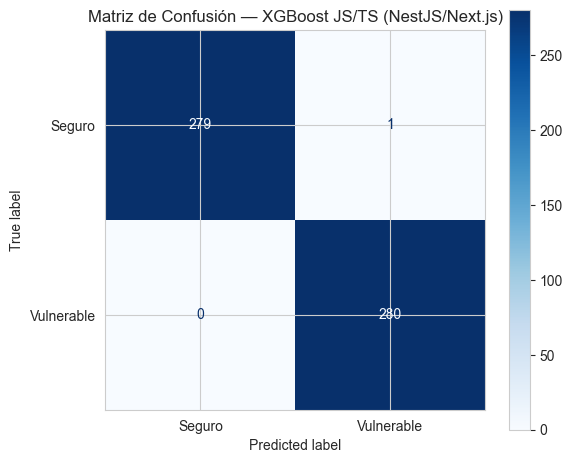

In [13]:
fig, ax = plt.subplots(figsize=(6,5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Seguro','Vulnerable']).plot(ax=ax, cmap='Blues')
ax.set_title('Matriz de Confusión — XGBoost JS/TS (NestJS/Next.js)')
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=150, bbox_inches='tight')
plt.show()


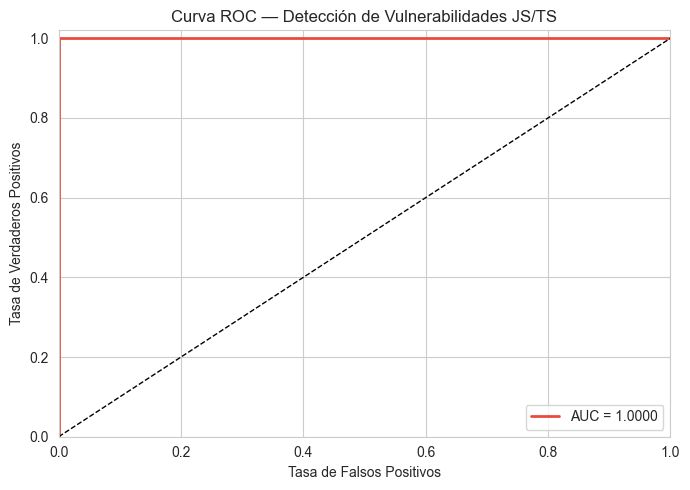

AUC-ROC: 1.0000


In [14]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'AUC = {roc_auc:.4f}')
plt.plot([0,1],[0,1],'k--',lw=1)
plt.xlim([0,1])
plt.ylim([0,1.02])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC — Detección de Vulnerabilidades JS/TS')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'AUC-ROC: {roc_auc:.4f}')


In [ ]:
explainer = LimeTextExplainer(class_names=['Seguro','Vulnerable'])

test_cases = [
    "const result = await this.repo.query(`SELECT * FROM users WHERE id = ${req.query.id}`);",
    "return <div dangerouslySetInnerHTML={{__html: req.body.content}} />;",
    "const fn = new Function('x', req.body.expr); fn();",
    "@Post() @UsePipes(ValidationPipe) create(@Body() dto: CreateUserDto) { return this.svc.create(dto); }",
    "const user = await prisma.user.findUnique({ where: { email: req.body.email } });",
    "const token = require('crypto').randomBytes(32).toString('hex');",
]

def predict_fn(texts):
    return best_model.predict_proba(texts)

print('Explicaciones LIME para casos representativos:\n')
for i, case in enumerate(test_cases):
    exp = explainer.explain_instance(case, predict_fn, num_features=6, top_labels=1)
    pred_label = best_model.predict([case])[0]
    pred_proba = best_model.predict_proba([case])[0]
    label_name = 'VULNERABLE' if pred_label==1 else 'SEGURO'
    print(f'Caso {i+1}: [{label_name}] confianza={max(pred_proba):.3f}')
    print(f'  {case[:80]}...')
    for token, weight in exp.as_list():
        d = '↑ Riesgo' if weight > 0 else '↓ Seguro'
        print(f"  '{token}': {weight:.4f} ({d})")
    print()


In [16]:
os.makedirs('models', exist_ok=True)
model_path = 'models/vulnerability_detector_js_ts.joblib'
joblib.dump(best_model, model_path)
print(f'Modelo exportado: {model_path}')
loaded = joblib.load(model_path)
print(f'Verificación OK — predicciones: {loaded.predict(X_test[:5])} | labels: {y_test[:5]}')


Modelo exportado: models/vulnerability_detector_js_ts.joblib
Verificación OK — predicciones: [0 0 0 0 1] | labels: [0 0 0 0 1]


In [17]:
def predict_vulnerability(code_snippet: str, model=None) -> dict:
    if model is None:
        model = best_model
    pred  = model.predict([code_snippet])[0]
    proba = model.predict_proba([code_snippet])[0]
    vuln_prob = proba[1]
    risk = 'CRÍTICO' if vuln_prob >= 0.8 else 'ALTO' if vuln_prob >= 0.6 else 'MEDIO' if vuln_prob >= 0.4 else 'BAJO'
    emoji = {'CRÍTICO':'🔴','ALTO':'🟠','MEDIO':'🟡','BAJO':'🟢'}[risk]
    return {
        'prediction': 'VULNERABLE' if pred==1 else 'SEGURO',
        'vulnerability_prob': round(float(vuln_prob), 4),
        'safe_prob': round(float(proba[0]), 4),
        'risk_level': risk, 'emoji': emoji,
    }

demos = [
    ('VULN', "const result = await connection.query(`SELECT * FROM users WHERE id = ${req.params.id}`);"),
    ('VULN', "eval(req.body.expression);"),
    ('VULN', "const hash = crypto.createHash('md5').update(password).digest('hex');"),
    ('VULN', "const data = await fetch(req.body.url);"),
    ('SEGURO', "@Post() @UsePipes(ValidationPipe) create(@Body() dto: CreateUserDto) { return this.svc.create(dto); }"),
    ('SEGURO', "const user = await prisma.user.findUnique({ where: { id: Number(req.params.id) } });"),
    ('SEGURO', "const token = crypto.randomBytes(32).toString('hex');"),
]

print('=' * 70)
print('DEMO — Detección de Vulnerabilidades JS/TS (NestJS/Next.js)')
print('=' * 70)
for expected, snippet in demos:
    r = predict_vulnerability(snippet)
    print(f"\n{r['emoji']} [{r['risk_level']}] {r['prediction']} ({r['vulnerability_prob']*100:.1f}%) | esperado: {expected}")
    print(f"   {snippet[:90]}{'...' if len(snippet) > 90 else ''}")


DEMO — Detección de Vulnerabilidades JS/TS (NestJS/Next.js)

🔴 [CRÍTICO] VULNERABLE (99.6%) | esperado: VULN
   const result = await connection.query(`SELECT * FROM users WHERE id = ${req.params.id}`);

🔴 [CRÍTICO] VULNERABLE (99.6%) | esperado: VULN
   eval(req.body.expression);

🔴 [CRÍTICO] VULNERABLE (99.5%) | esperado: VULN
   const hash = crypto.createHash('md5').update(password).digest('hex');

🔴 [CRÍTICO] VULNERABLE (99.4%) | esperado: VULN
   const data = await fetch(req.body.url);

🟢 [BAJO] SEGURO (0.5%) | esperado: SEGURO
   @Post() @UsePipes(ValidationPipe) create(@Body() dto: CreateUserDto) { return this.svc.cre...

🟢 [BAJO] SEGURO (0.7%) | esperado: SEGURO
   const user = await prisma.user.findUnique({ where: { id: Number(req.params.id) } });

🟢 [BAJO] SEGURO (0.9%) | esperado: SEGURO
   const token = crypto.randomBytes(32).toString('hex');


In [18]:
print('=' * 60)
print('RESUMEN — SEMMA: Detección de Vulnerabilidades JS/TS')
print('=' * 60)
print(f'  Ecosistema:       NestJS + Next.js (TypeScript/JavaScript)')
print(f'  Total muestras:   {len(df)}')
print(f'  CWEs cubiertos:   9 (CWE-89, 78, 94, 502, 22, 79, 327, 918, 20)')
print(f'  Features:         TF-IDF char(2-5) + word(1-3) + Patrones de seguridad')
print(f'  Modelo:           XGBoost + GridSearchCV (5-fold Stratified CV)')
print(f'  Accuracy:         {accuracy_score(y_test, y_pred):.4f}')
print(f'  F1 Score:         {f1_score(y_test, y_pred):.4f}')
print(f'  AUC-ROC:          {roc_auc:.4f}')
print(f'  Modelo exportado: models/vulnerability_detector_js_ts.joblib')
print('=' * 60)


RESUMEN — SEMMA: Detección de Vulnerabilidades JS/TS
  Ecosistema:       NestJS + Next.js (TypeScript/JavaScript)
  Total muestras:   2800
  CWEs cubiertos:   9 (CWE-89, 78, 94, 502, 22, 79, 327, 918, 20)
  Features:         TF-IDF char(2-5) + word(1-3) + Patrones de seguridad
  Modelo:           XGBoost + GridSearchCV (5-fold Stratified CV)
  Accuracy:         0.9982
  F1 Score:         0.9982
  AUC-ROC:          1.0000
  Modelo exportado: models/vulnerability_detector_js_ts.joblib
